In [1]:
# Import required libraries
import wrds
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [2]:
# Connect to WRDS database 
db = wrds.Connection()
print("✅ Connected to WRDS successfully")

Enter your WRDS username [miaod]: duyumiao
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\miaod\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
✅ Connected to WRDS successfully


In [14]:
# WRDS permanent stock codes 
permnos = [14593, 10107, 12490]  # AAPL=14593, MSFT=10107, IBM=12490
tickers = ['AAPL', 'MSFT', 'IBM']
start_date = '2022-01-01'
end_date = '2024-12-31'

# Convert parameters to SQL-compatible format
permno_str = ", ".join(map(str, permnos))
permno_ticker_map = dict(zip(permnos, tickers))
ticker_str = "','".join(tickers)

print("✅ Parameters set successfully (3 companies with full data)")

✅ Parameters set successfully (3 companies with full data)


In [15]:
# Fetch daily stock price data from CRSP 
price_df = db.raw_sql(f"""
    SELECT date, permno, prc
    FROM crsp.dsf
    WHERE permno IN ({permno_str})
    AND date >= '{start_date}'
    AND date <= '{end_date}'
""")

# Data cleaning
price_df['date'] = pd.to_datetime(price_df['date'])
price_df['prc'] = price_df['prc'].abs()  # Fix CRSP negative price convention
price_df['ticker'] = price_df['permno'].map(permno_ticker_map)
price_df = price_df.dropna(subset=['prc', 'ticker'])

print("✅ Stock price data loaded successfully (3 companies)")

✅ Stock price data loaded successfully (3 companies)


In [16]:
# Fetch financial data from Compustat
fin_df = db.raw_sql(f"""
    SELECT datadate, tic, revt, ni
    FROM comp.funda
    WHERE tic IN ('{ticker_str}')
    AND datadate >= '2021-12-31'
    AND datadate <= '2024-12-31'
    AND indfmt='INDL' 
    AND datafmt='STD'
    AND popsrc='D' 
    AND consol='C'
""")

# Data cleaning
fin_df['datadate'] = pd.to_datetime(fin_df['datadate'])
fin_df.rename(columns={'tic':'ticker'}, inplace=True)
fin_df = fin_df.dropna(subset=['ticker', 'revt', 'ni'])

print("✅ Financial data loaded successfully (3 companies)")

✅ Financial data loaded successfully (3 companies)


In [17]:
# Process yearly average stock prices
price_year = price_df.copy()
price_year['year'] = price_year['date'].dt.year
price_year = price_year.groupby(['ticker', 'year'])['prc'].mean().reset_index()
price_year.rename(columns={'prc':'price'}, inplace=True)

# Process yearly financial data
fin_year = fin_df.copy()
fin_year['year'] = fin_year['datadate'].dt.year
fin_year = fin_year.groupby(['ticker', 'year'])[['revt', 'ni']].mean().reset_index()

# Merge price and financial data (inner join is safe - no missing data)
final_df = pd.merge(price_year, fin_year, on=['ticker', 'year'], how='inner')

print("✅ Data merged successfully (3 companies, no missing data)")
print("✅ Check companies:", final_df['ticker'].unique())

✅ Data merged successfully (3 companies, no missing data)
✅ Check companies: ['AAPL' 'IBM' 'MSFT']


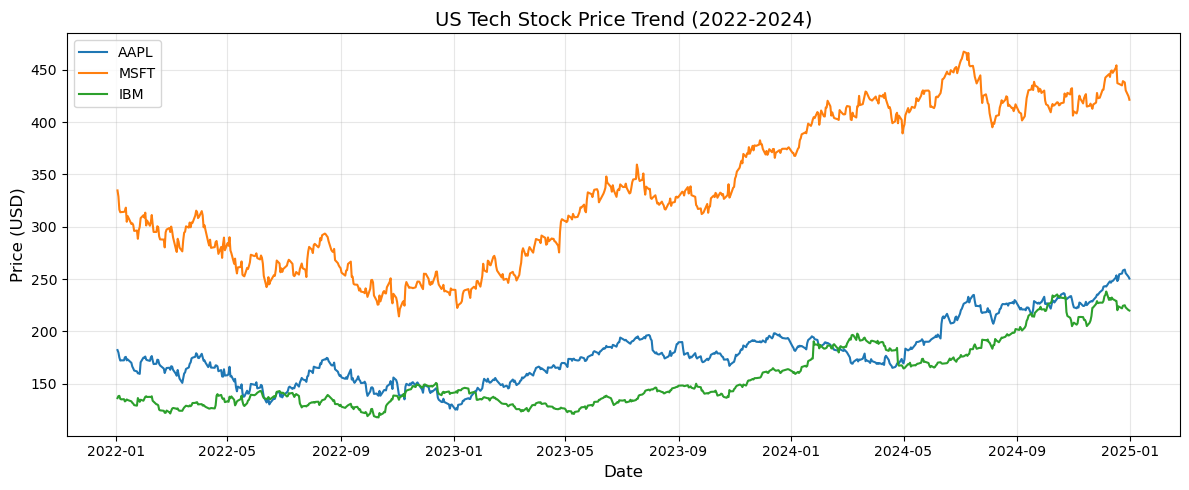

In [18]:
# Plot daily stock price trend (3 companies)
plt.figure(figsize=(12, 5))
for ticker in tickers:
    ticker_data = price_df[price_df['ticker'] == ticker]
    plt.plot(ticker_data['date'], ticker_data['prc'], label=ticker, linewidth=1.5)

plt.title('US Tech Stock Price Trend (2022-2024)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

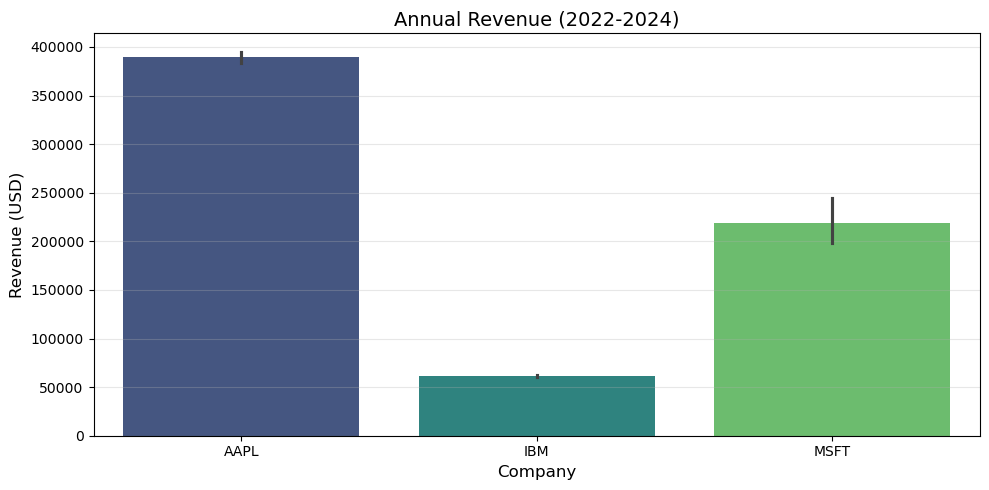

In [19]:
# Plot annual revenue by company (3 companies, no warnings)
plt.figure(figsize=(10, 5))
sns.barplot(x='ticker', y='revt', data=final_df, palette='viridis', hue='ticker', legend=False)
plt.title('Annual Revenue (2022-2024)', fontsize=14)
plt.xlabel('Company', fontsize=12)
plt.ylabel('Revenue (USD)', fontsize=12)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

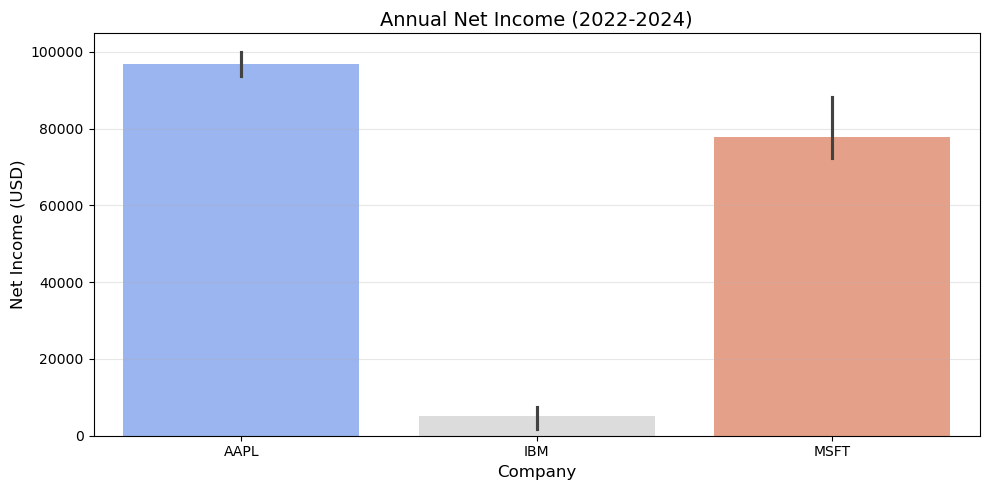

In [20]:
# Plot annual net income by company (3 companies, no warnings)
plt.figure(figsize=(10, 5))
sns.barplot(x='ticker', y='ni', data=final_df, palette='coolwarm', hue='ticker', legend=False)
plt.title('Annual Net Income (2022-2024)', fontsize=14)
plt.xlabel('Company', fontsize=12)
plt.ylabel('Net Income (USD)', fontsize=12)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [3]:
# Close WRDS connection
db.close()
print("ALL ANALYSIS COMPLETED - 3 COMPANIES WITH FULL DATA!")

ALL ANALYSIS COMPLETED - 3 COMPANIES WITH FULL DATA!
